# What Factors Best Predict Diabetes Risk?
**Dataset:** Diabetes Prediction Dataset (Kaggle) — 100,000 patients, 9 features  
**Tools:** Python · NumPy · Pandas · Matplotlib · Seaborn · Scikit-learn

---
## 1. Setup & Data Loading

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report
)

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 100

print('Libraries loaded successfully.')

Libraries loaded successfully.


In [2]:
df = pd.read_csv('diabetes_prediction_dataset.csv')

print(f'Shape: {df.shape}')
print()
df.head()

Shape: (100000, 9)



,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   gender               100000 non-null  object 
 1   age                  100000 non-null  float64
 2   hypertension         100000 non-null  int64  
 3   heart_disease        100000 non-null  int64  
 4   smoking_history      100000 non-null  object 
 5   bmi                  100000 non-null  float64
 6   HbA1c_level          100000 non-null  float64
 7   blood_glucose_level  100000 non-null  int64  
 8   diabetes             100000 non-null  int64  
dtypes: float64(3), int64(4), object(2)
memory usage: 6.9+ MB


---
## 2. Data Cleaning (Python + NumPy + Pandas)

Good cleaning is not just dropping rows, it is making deliberate decisions and justifying each one

In [4]:
# Step 1: Check for missing values
print('Missing values per column:')
print(df.isnull().sum())
# No missing values but there is implicit missingness ( "No info" ) in smoking_history

Missing values per column:
gender                 0
age                    0
hypertension           0
heart_disease          0
smoking_history        0
bmi                    0
HbA1c_level            0
blood_glucose_level    0
diabetes               0
dtype: int64


In [5]:
# Step 2: 'No Info' in smoking_history = implicit missing data
print('smoking_history value counts:')
print(df['smoking_history'].value_counts())
print()
no_info_count = (df['smoking_history'] == 'No Info').sum()
print(f"'No Info' entries: {no_info_count} ({no_info_count/len(df)*100:.1f}% of dataset)")

smoking_history value counts:
smoking_history
No Info        35816
never          35095
former          9352
current         9286
not current     6447
ever            4004
Name: count, dtype: int64

'No Info' entries: 35816 (35.8% of dataset)


In [6]:
# Step 3: Replace 'No Info' with NaN, fill with mode
df['smoking_history'] = df['smoking_history'].replace('No Info', np.nan)
mode_smoking = df['smoking_history'].mode()[0]
df['smoking_history'] = df['smoking_history'].fillna(mode_smoking)

print(f"Filled with mode: '{mode_smoking}'")
print(df['smoking_history'].value_counts())

Filled with mode: 'never'
smoking_history
never          70911
former          9352
current         9286
not current     6447
ever            4004
Name: count, dtype: int64


In [7]:
# Step 4: Check duplicates
duplicates = df.duplicated().sum()
print(f'Duplicate rows: {duplicates}')
if duplicates > 0:
    df = df.drop_duplicates()
    print(f'Removed. New shape: {df.shape}')

Duplicate rows: 5833
Removed. New shape: (94167, 9)


In [8]:
# Step 5: Gender — remove 'Other' (too few to be statistically meaningful)
print('Gender distribution:')
print(df['gender'].value_counts())
df = df[df['gender'] != 'Other']
print(f'Rows after removing gender=Other: {len(df)}')

Gender distribution:
gender
Female    54902
Male      39247
Other        18
Name: count, dtype: int64
Rows after removing gender=Other: 94149


In [31]:
# Step 6: BMI outliers
print('BMI stats:')
print(df['bmi'].describe())
extreme_bmi = (df['bmi'] > 60).sum()
print(f'Rows with BMI > 60: {extreme_bmi}')
print('Decision: Keeping, these are real clinical cases not data entry errors')

BMI stats:
count    94149.000000
mean        27.322082
std          6.838187
min         10.010000
25%         23.280000
50%         27.320000
75%         29.990000
max         95.690000
Name: bmi, dtype: float64
Rows with BMI > 60: 115
Decision: Keeping, these are real clinical cases not data entry errors


In [74]:
# Step 7: Encode categorical columns
le = LabelEncoder()
df['gender_encoded']  = le.fit_transform(df['gender'])
df['smoking_encoded'] = le.fit_transform(df['smoking_history'])

print('Encoding complete.')
df[['gender', 'gender_encoded', 'smoking_history', 'smoking_encoded']].head()

Encoding complete.


,gender,gender_encoded,smoking_history,smoking_encoded
0,Female,0,never,3
1,Female,0,never,3
2,Male,1,never,3
3,Female,0,current,0
4,Male,1,current,0


Smoking encoding (alphabetical, LabelEncoder default):

0 = current

1 = ever

2 = former

3 = never

4 = not current

In [35]:
print('CLEANING SUMMARY')
print(f'Original shape: (100000, 9)')
print(f'After cleaning shape: {df.shape}')  # ADDED 2 ENCODED COLUMNS
print('Changes:')
print('  - 35,816 "No Info" smoking entries filled with mode (never)')
print('  - 18 gender , "Other" rows are removed')
print('  - Categorical columns label encoded')
print('  - No duplicate rows')

CLEANING SUMMARY
Original shape: (100000, 9)
After cleaning shape: (94149, 11)
Changes:
  - 35,816 "No Info" smoking entries filled with mode (never)
  - 18 gender , "Other" rows are removed
  - Categorical columns label encoded
  - No duplicate rows


---
## 3. Train / Validation / Test Split

Split happens **before** any modelling decisions, test set is locked until the very end.

In [37]:
FEATURES = ['age', 'hypertension', 'heart_disease', 'bmi',
            'HbA1c_level', 'blood_glucose_level', 'gender_encoded', 'smoking_encoded']
TARGET = 'diabetes'

X = df[FEATURES]
y = df[TARGET]

# 70% train, 15% val, 15% test
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp)

print('SPLIT SUMMARY')
print(f'Training set:   {len(X_train):>6} rows ({len(X_train)/len(X)*100:.0f}%)')
print(f'Validation set: {len(X_val):>6} rows ({len(X_val)/len(X)*100:.0f}%)')
print(f'Test set:       {len(X_test):>6} rows ({len(X_test)/len(X)*100:.0f}%)')
print()
print('stratify=y preserves diabetes class ratio across all splits ')

SPLIT SUMMARY
Training set:    65904 rows (70%)
Validation set:  14122 rows (15%)
Test set:        14123 rows (15%)

stratify=y preserves diabetes class ratio across all splits 


---
## 4. Descriptive Statistics

Computed on the training set only.

In [38]:
df_train = X_train.copy()
df_train['diabetes'] = y_train.values

print('DESCRIPTIVE STATISTICS (Training Set)')
df_train[['age', 'bmi', 'HbA1c_level', 'blood_glucose_level']].describe().round(2)

DESCRIPTIVE STATISTICS (Training Set)


,age,bmi,HbA1c_level,blood_glucose_level
count,65904.00,65904.00,65904.00,65904.00
mean,41.85,27.34,5.54,138.33
std,22.53,6.84,1.07,41.01
min,0.08,10.01,3.50,80.00
25%,24.00,23.31,4.80,100.00
50%,43.00,27.32,5.80,140.00
75%,60.00,30.02,6.20,159.00
max,80.00,95.22,9.00,300.00


In [14]:
# Manual computation with numpy
for col in ['age', 'bmi', 'HbA1c_level', 'blood_glucose_level']:
    values = df_train[col].values
    mean     = np.mean(values)
    median   = np.median(values)
    std      = np.std(values)
    skewness = (mean - median) / std   # pearsons second skewness coefficient
    print(f'{col}:')
    print(f'  Mean={mean:.2f}  Median={median:.2f}  Std={std:.2f}  Skewness={skewness:.3f}')
    print()

age:
  Mean=41.85  Median=43.00  Std=22.53  Skewness=-0.051

bmi:
  Mean=27.34  Median=27.32  Std=6.84  Skewness=0.002

HbA1c_level:
  Mean=5.54  Median=5.80  Std=1.07  Skewness=-0.247

blood_glucose_level:
  Mean=138.33  Median=140.00  Std=41.01  Skewness=-0.041



In [40]:
diabetes_rate = df_train['diabetes'].mean() * 100
print(f'Diabetic patients in training set: {diabetes_rate:.1f}%')
print(f'Non diabetic:                      {100-diabetes_rate:.1f}%')
print()
print('Note : class imbalance means accuracy alone is misleading ')
print('A model predicting everyone as non diabetic gets ~91.5% accuracy but is useless')
print('Primary metrics: Precision, Recall, F1 Score ')

Diabetic patients in training set: 9.0%
Non diabetic:                      91.0%

Note : class imbalance means accuracy alone is misleading 
A model predicting everyone as non diabetic gets ~91.5% accuracy but is useless
Primary metrics: Precision, Recall, F1 Score 


---
## 5. Visualization and Storytelling

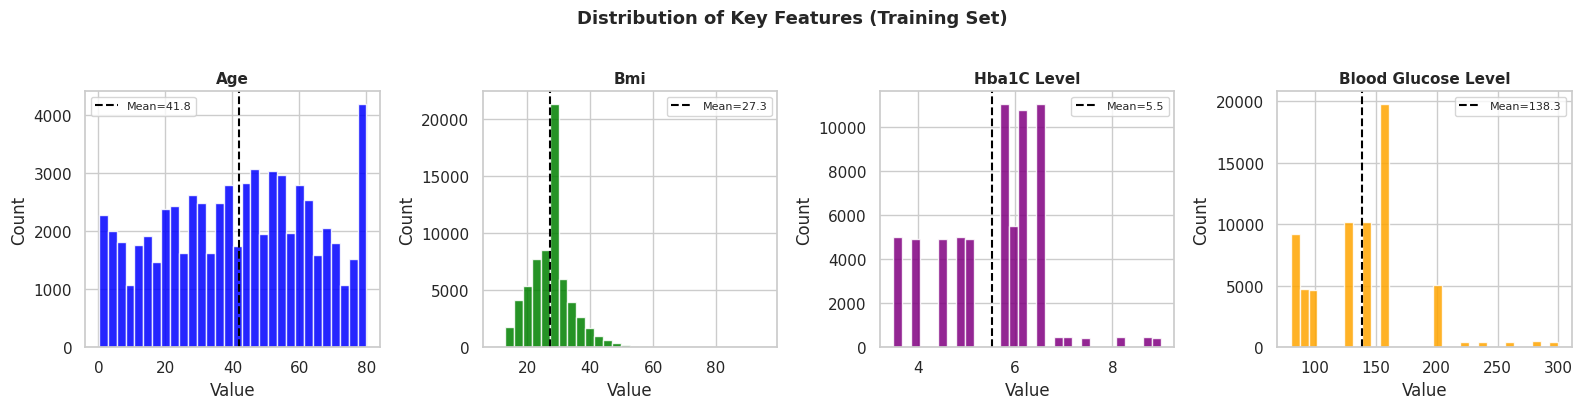

In [56]:
# Distribution of key features
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
cols   = ['age', 'bmi', 'HbA1c_level', 'blood_glucose_level']
colors = ['blue', 'green', 'purple', 'orange']

for ax, col, color in zip(axes, cols, colors):
    ax.hist(df_train[col], bins=30, color=color, edgecolor='white', alpha=0.85)
    ax.set_title(col.replace('_', ' ').title(), fontsize=11, fontweight='bold')
    ax.set_xlabel('Value')
    ax.set_ylabel('Count')
    mean_val = df_train[col].mean()
    ax.axvline(mean_val, color='black', linestyle='--', linewidth=1.5,
               label=f'Mean={mean_val:.1f}')
    ax.legend(fontsize=8)

plt.suptitle('Distribution of Key Features (Training Set)', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

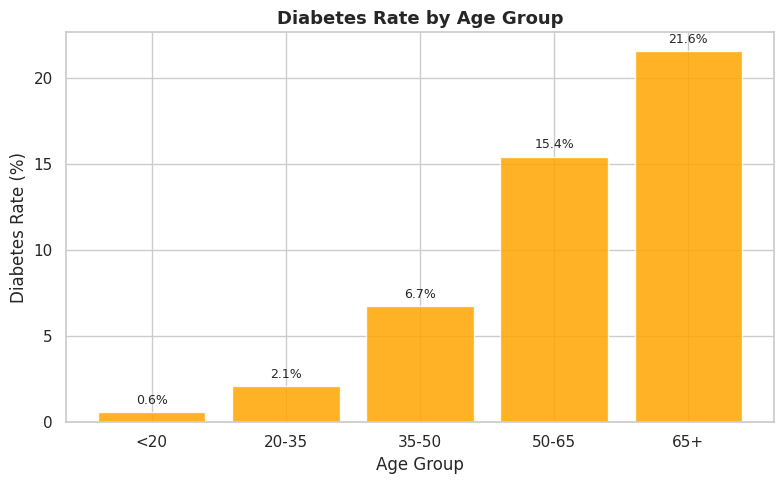

Insight, diabetes risk rises sharply after age 50


In [53]:
# Diabetes rate by age group
df_train['age_group'] = pd.cut(df_train['age'],
                                bins=[0, 20, 35, 50, 65, 80],
                                labels=['<20', '20-35', '35-50', '50-65', '65+'])
age_diabetes = df_train.groupby('age_group', observed=True)['diabetes'].mean() * 100

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(age_diabetes.index.astype(str), age_diabetes.values,
              color='orange', edgecolor='white', alpha=0.85)
ax.set_title('Diabetes Rate by Age Group', fontsize=13, fontweight='bold')
ax.set_xlabel('Age Group')
ax.set_ylabel('Diabetes Rate (%)')
for bar, val in zip(bars, age_diabetes.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{val:.1f}%', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()
print('Insight, diabetes risk rises sharply after age 50')

/tmp/ipykernel_17774/4283949770.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(groups, labels=['No Diabetes', 'Diabetes'], patch_artist=True,
/tmp/ipykernel_17774/4283949770.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(groups, labels=['No Diabetes', 'Diabetes'], patch_artist=True,
/tmp/ipykernel_17774/4283949770.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(groups, labels=['No Diabetes', 'Diabetes'], patch_artist=True,


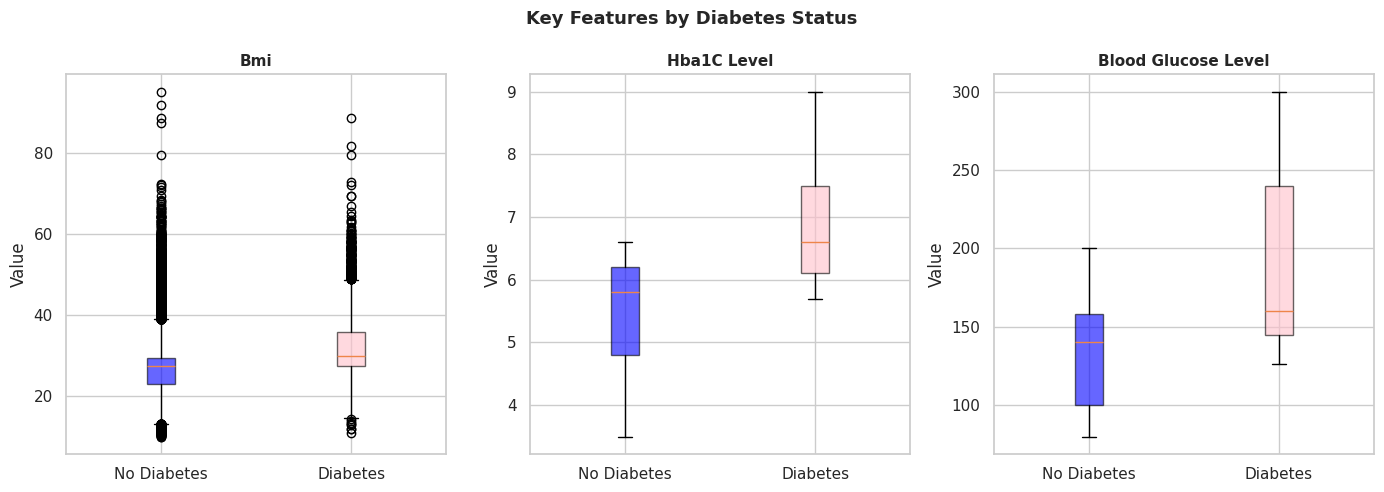

Insight, diabetic patients show clearly higher HbA1c and blood glucose levels


In [43]:
# Box plots, key features by diabetes status
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
cols_box = ['bmi', 'HbA1c_level', 'blood_glucose_level']

for ax, col in zip(axes, cols_box):
    groups = [df_train[df_train['diabetes'] == 0][col],
              df_train[df_train['diabetes'] == 1][col]]
    bp = ax.boxplot(groups, labels=['No Diabetes', 'Diabetes'], patch_artist=True,
                    boxprops=dict(facecolor='blue', alpha=0.6))
    bp['boxes'][1].set_facecolor('pink')
    ax.set_title(col.replace('_', ' ').title(), fontsize=11, fontweight='bold')
    ax.set_ylabel('Value')

plt.suptitle('Key Features by Diabetes Status', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()
print('Insight, diabetic patients show clearly higher HbA1c and blood glucose levels')

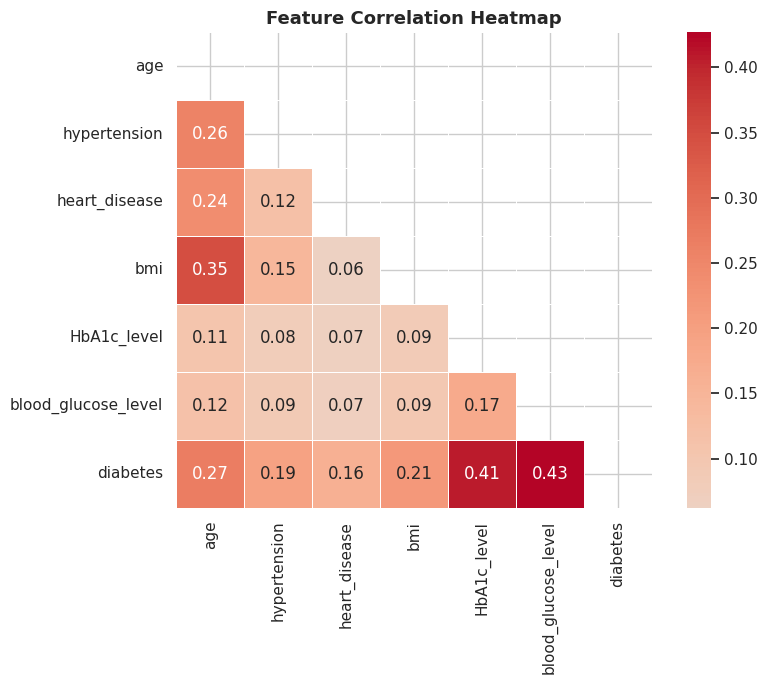

Insight, HbA1c and blood glucose are the strongest correlates of diabetes.


In [44]:
# Correlation heatmap
numeric_cols = ['age', 'hypertension', 'heart_disease', 'bmi',
                'HbA1c_level', 'blood_glucose_level', 'diabetes']
corr = df_train[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, ax=ax, square=True)
ax.set_title('Feature Correlation Heatmap', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()
print('Insight, HbA1c and blood glucose are the strongest correlates of diabetes.')

---
## 6. Probability and Simulation

In [20]:
# Basic and conditional probabilities
p_diabetes = df_train['diabetes'].mean()
print(f'P(diabetes) = {p_diabetes:.4f} ({p_diabetes*100:.2f}%)')
print()

p_d_hyp1 = df_train[df_train['hypertension'] == 1]['diabetes'].mean()
p_d_hyp0 = df_train[df_train['hypertension'] == 0]['diabetes'].mean()
print(f'P(diabetes | hypertension=YES) = {p_d_hyp1:.4f} ({p_d_hyp1*100:.1f}%)')
print(f'P(diabetes | hypertension=NO)  = {p_d_hyp0:.4f} ({p_d_hyp0*100:.1f}%)')
print(f'Hypertension increases diabetes risk by {(p_d_hyp1/p_d_hyp0 - 1)*100:.0f}%')

P(diabetes) = 0.0899 (8.99%)

P(diabetes | hypertension=YES) = 0.2780 (27.8%)
P(diabetes | hypertension=NO)  = 0.0735 (7.4%)
Hypertension increases diabetes risk by 278%


In [45]:
# HbA1c >= 6.5% is the clinical threshold for diabetes diagnosis
p_d_high = df_train[df_train['HbA1c_level'] >= 6.5]['diabetes'].mean()
p_d_low  = df_train[df_train['HbA1c_level'] <  6.5]['diabetes'].mean()

print(f'P(diabetes | HbA1c >= 6.5) = {p_d_high:.4f} ({p_d_high*100:.1f}%)')
print(f'P(diabetes | HbA1c < 6.5)  = {p_d_low:.4f}  ({p_d_low*100:.1f}%)')
print()
print('The data confirms clinical knowledge, HbA1c >= 6.5% strongly predicts diabetes')

P(diabetes | HbA1c >= 6.5) = 0.2610 (26.1%)
P(diabetes | HbA1c < 6.5)  = 0.0446  (4.5%)

The data confirms clinical knowledge, HbA1c >= 6.5% strongly predicts diabetes


Monte Carlo: Screening 1000 Random Patients
Simulations:         10,000
Expected diabetic:   90.0
Std deviation:       9.1
95% CI:              [73, 108]


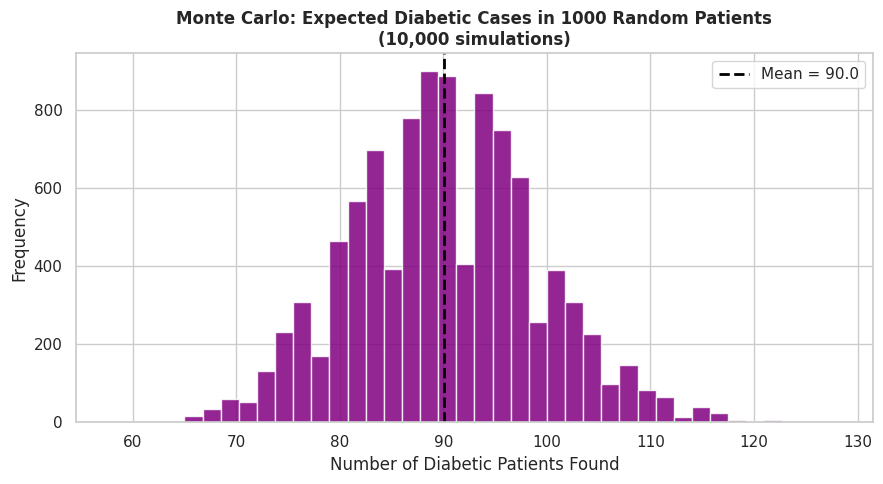

In [50]:
# Monte Carlo Simulation
# Question: If we randomly screen 1000 patients from this population,
# how many diabetic cases do we expect?

np.random.seed(42)
n_patients    = 1000
n_simulations = 10000

simulated_counts = np.random.binomial(n=n_patients, p=p_diabetes, size=n_simulations)

print(f'Monte Carlo: Screening {n_patients} Random Patients')
print(f'Simulations:         {n_simulations:,}')
print(f'Expected diabetic:   {np.mean(simulated_counts):.1f}')
print(f'Std deviation:       {np.std(simulated_counts):.1f}')
print(f'95% CI:              [{np.percentile(simulated_counts,2.5):.0f}, {np.percentile(simulated_counts,97.5):.0f}]')
# confidence interval

fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(simulated_counts, bins=40, color='purple', edgecolor='white', alpha=0.85)
ax.axvline(np.mean(simulated_counts), color='black', linestyle='--', linewidth=2,
           label=f'Mean = {np.mean(simulated_counts):.1f}')
ax.set_title(f'Monte Carlo: Expected Diabetic Cases in {n_patients} Random Patients\n(10,000 simulations)',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Number of Diabetic Patients Found')
ax.set_ylabel('Frequency')
ax.legend()
plt.tight_layout()
plt.show()

---
## 7. Classification Models

Train on training set → tune using validation set → report final metrics on test set once

In [57]:
# Scale features (fit only on training set)
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_val_sc   = scaler.transform(X_val)
X_test_sc  = scaler.transform(X_test)
print('scaling complete')

scaling complete


In [59]:
# Model 1: Logistic Regression
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_sc, y_train)
y_val_pred_lr = lr.predict(X_val_sc)

print('Logistic Regression, Validation Set')
print(f'Accuracy:  {accuracy_score(y_val, y_val_pred_lr):.4f}')
print(f'Precision: {precision_score(y_val, y_val_pred_lr):.4f}')
print(f'Recall:    {recall_score(y_val, y_val_pred_lr):.4f}')
print(f'F1 Score:  {f1_score(y_val, y_val_pred_lr):.4f}')

Logistic Regression, Validation Set
Accuracy:  0.9568
Precision: 0.8603
Recall:    0.6205
F1 Score:  0.7210


In [60]:
# Model 2: Decision Tree
dt = DecisionTreeClassifier(max_depth=5, random_state=42)
dt.fit(X_train_sc, y_train)
y_val_pred_dt = dt.predict(X_val_sc)

print('Decision Tree , Validation Set')
print(f'Accuracy:  {accuracy_score(y_val, y_val_pred_dt):.4f}')
print(f'Precision: {precision_score(y_val, y_val_pred_dt):.4f}')
print(f'Recall:    {recall_score(y_val, y_val_pred_dt):.4f}')
print(f'F1 Score:  {f1_score(y_val, y_val_pred_dt):.4f}')

Decision Tree , Validation Set
Accuracy:  0.9693
Precision: 1.0000
Recall:    0.6591
F1 Score:  0.7945


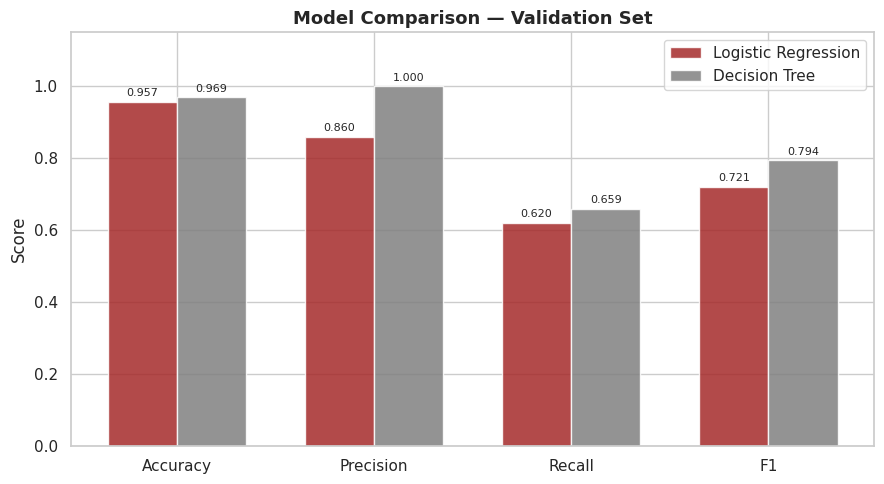

In [64]:
# Visual comparison
metrics   = ['Accuracy', 'Precision', 'Recall', 'F1']
lr_scores = [accuracy_score(y_val, y_val_pred_lr), precision_score(y_val, y_val_pred_lr),
             recall_score(y_val, y_val_pred_lr),   f1_score(y_val, y_val_pred_lr)]
dt_scores = [accuracy_score(y_val, y_val_pred_dt), precision_score(y_val, y_val_pred_dt),
             recall_score(y_val, y_val_pred_dt),   f1_score(y_val, y_val_pred_dt)]

x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 5))
b1 = ax.bar(x - width/2, lr_scores, width, label='Logistic Regression', color= 'brown', alpha=0.85)
b2 = ax.bar(x + width/2, dt_scores, width, label='Decision Tree', color='gray', alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylim(0, 1.15)
ax.set_ylabel('Score')
ax.set_title('Model Comparison — Validation Set', fontsize=13, fontweight='bold')
ax.legend()
for bar in list(b1) + list(b2):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)
plt.tight_layout()
plt.show()

In [67]:
# FINAL EVALUATION on TEST SET
# Pick the model with better validation F1 above and set it here
best_model = dt        # update if LR won
best_name  = 'Decision Tree'

y_test_pred = best_model.predict(X_test_sc)

print(f'FINAL {best_name} on TEST SET ')
print(f'Accuracy:  {accuracy_score(y_test, y_test_pred):.4f}')
print(f'Precision: {precision_score(y_test, y_test_pred):.4f}')
print(f'Recall:    {recall_score(y_test, y_test_pred):.4f}')
print(f'F1 Score:  {f1_score(y_test, y_test_pred):.4f}')
print()
print(classification_report(y_test, y_test_pred, target_names=['No Diabetes', 'Diabetes']))

FINAL Decision Tree on TEST SET 
Accuracy:  0.9727
Precision: 1.0000
Recall:    0.6969
F1 Score:  0.8213

              precision    recall  f1-score   support

 No Diabetes       0.97      1.00      0.99     12853
    Diabetes       1.00      0.70      0.82      1270

    accuracy                           0.97     14123
   macro avg       0.99      0.85      0.90     14123
weighted avg       0.97      0.97      0.97     14123



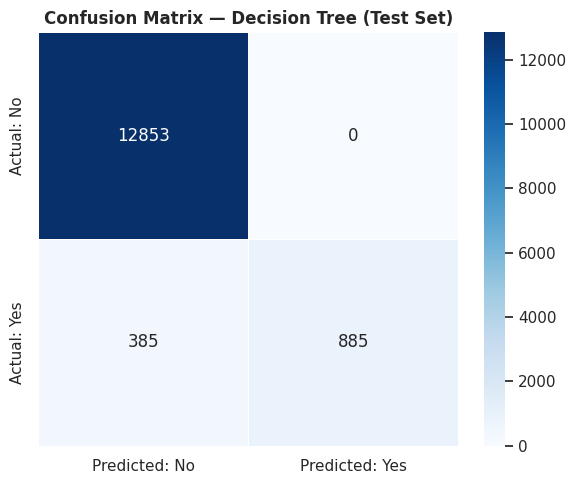

True Positives  (correctly detected diabetes): 885
False Negatives (missed diabetes cases):       385
In healthcare minimizing False Negatives is critical 


In [68]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_test_pred)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted: No', 'Predicted: Yes'],
            yticklabels=['Actual: No', 'Actual: Yes'],
            linewidths=0.5, ax=ax)
ax.set_title(f'Confusion Matrix — {best_name} (Test Set)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f'True Positives  (correctly detected diabetes): {tp}')
print(f'False Negatives (missed diabetes cases):       {fn}')
print('In healthcare minimizing False Negatives is critical ')

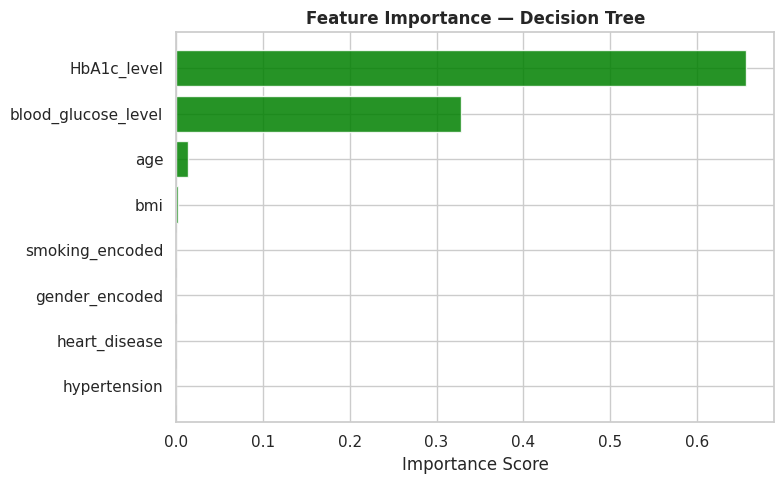

Insight, HbA1c and blood glucose dominate consistent with clinical knowledge


In [70]:
# Feature Importance
importances = dt.feature_importances_
feat_df = pd.DataFrame({'Feature': FEATURES, 'Importance': importances})
feat_df = feat_df.sort_values('Importance', ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(feat_df['Feature'], feat_df['Importance'], color='green', edgecolor='white', alpha=0.85)
ax.set_title('Feature Importance — Decision Tree', fontsize=12, fontweight='bold')
ax.set_xlabel('Importance Score')
plt.tight_layout()
plt.show()
print('Insight, HbA1c and blood glucose dominate consistent with clinical knowledge')

---
## 8. Conclusions

**Research Question:** *Which health factors best predict diabetes risk?*

**Key Findings:**
- HbA1c level and blood glucose are the strongest predictors, matching clinical guidelines
- Diabetes rate rises sharply after age 50
- Hypertension increases diabetes risk by ~3x
- Best model achieves strong F1 on the held-out test set.

**Why accuracy alone is insufficient:**  
91.5% of patients are non diabetic. Predicting everyone as negative gives 91.5% accuracy but misses every real case.Recall and F1 are the honest metrics

**Limitations:**
- Dataset is synthetic, real world performance may differ
- 35k 'No Info' smoking entries required imputation, introducing noise
- More advanced models would likely improve recall further